# BYOL Downstream Classification Evaluation — LoTSS

Evaluates BYOL encoder representations on the LoTSS 5-class (`initial_pure`) task,
using the train/test split produced by the BYOL training run.

All **configurations** (`CONFIG`, `GRID_CONFIG`, `CM_CONFIG`) are defined in Section 0.
All **imports** are collected in Section 1.

Sections:
- **0** Configuration (`CONFIG`, `GRID_CONFIG`, `CM_CONFIG`)
- **1** Imports & Setup
- **2** Load Encoder
- **3** Load Projections (from BYOL run)
- **4** Classifier Utilities (`run_linear_probe`, `run_classifier_suite`)
- **5** Classifier Suite — load pre-computed or train on site (LR / KNN / RF / MLP)
- **6** Supervised Baseline Comparison
- **6b** Fine-tuning Comparison (per-class metrics across training modes)
- **6c** F1 vs Label Fraction (BYOL LR probe / finetuned / supervised baseline)
- **7** Hyperparameter Sweep Grid
- **8** Confusion Matrix (BYOL LR / Finetuned / Supervised)
- **9** Label-Fraction Experiment
- **10** Generative Augmentation Experiment

## 0. Configuration

Edit `CONFIG` to point to the target BYOL checkpoint and set output paths.
`GRID_CONFIG` controls the hyperparameter sweep axes (Section 7).
`CM_CONFIG` controls which classifiers appear in the confusion matrix (Section 8).

In [44]:
CONFIG = {
    # ── Main BYOL run (Sections 2–5, 8–9) ─────────────────────────────────────
    "checkpoint":    "../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt",
    "catalogue":     "../catalogues/lotss_initial_all.yaml",
    "colour_by":     "dataset",   # "dataset" | "label"
    "root":          "..",

    # ── Classification evaluation ──────────────────────────────────────────────
    "label_set":     "initial_pure",

    # ── Supervised baselines (Section 6) ──────────────────────────────────────
    "baselines_dir": "../outputs/supervised_baseline_classifiers",

    # ── Fine-tuning runs (Sections 6b, 6c) ────────────────────────────────────
    "finetuning_runs": [
        "../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/",
    ],
    "finetuning_types": [          # all types compared in Section 6b
        "finetuning_mode1_lr1e-4_ep30",
        "finetuning_mode2_lr1e-4_ep30",
        "finetuning_mode3_lr1e-4_ep30",
    ],
    "finetuning_type": "finetuning_mode1_lr1e-4_ep30",   # single type used in Section 6c

    # ── BYOL runs root (Section 6c) ───────────────────────────────────────────
    "byol_runs_dir": "../outputs/byol_runs",
}

# ── Hyperparameter sweep (Section 7) ──────────────────────────────────────────
GRID_CONFIG = {
    "axis_x":        "f",            # label fraction  (f0, f0.1, f0.5, f1 …)
    "axis_y":        "sw",           # supervision wt  (sw0.01, sw0.1, sw1 …)
    "classifier":    "rf",           # rf | knn | lr
    "label_set":     "initial_pure",
    "feature_type":  "projections",
    "outputs_root":  "../outputs/byol_runs",
    "run_glob":      "enb0_*",
}

# ── Confusion matrix (Section 8) ──────────────────────────────────────────────
CM_CONFIG = {
    "label_set":       "initial_pure",
    "byol_classifier": "linear_probe",   # "random_forest" | "knn" | "linear_probe"
    "baseline_model":  "enb0",           # substring matched against baseline run dir names
    "baseline_dir":    "../outputs/supervised_baseline_classifiers",
    "n_estimators":    200,
    "n_neighbors":     15,
}

OUT_DIR = "../outputs/figures/classification"
SEED    = 42

## 1. Imports & Setup

All third-party imports and project-local imports (`load_encoder`, `ALL_CLASS_NAMES`, `LABEL_SETS`).
`OUT_DIR` is created here if it does not exist.

In [45]:
import os, sys, re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import ipywidgets as widgets
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

# Add project src and scripts to path
_root = os.path.abspath("..")
for _p in [os.path.join(_root, "src"), os.path.join(_root, "scripts")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from embed_and_umap import load_encoder
from train_byol_classifiers import ALL_CLASS_NAMES, LABEL_SETS

os.makedirs(OUT_DIR, exist_ok=True)
print("Imports OK")

Imports OK


## 2. Load Encoder

Loads the BYOL checkpoint and returns the online encoder + projector. Auto-detects model type from the checkpoint config.

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

encoder, projector = load_encoder(CONFIG["checkpoint"], device)
encoder.eval()
projector.eval()

# Detect dimensions via dummy forward pass
with torch.no_grad():
    _dummy   = torch.zeros(1, 1, 89, 89).to(device)
    enc_dim  = encoder(_dummy).shape[-1]
    proj_dim = projector(encoder(_dummy)).shape[-1]

print(f"\nEncoder output dim  : {enc_dim}")
print(f"Projector output dim: {proj_dim}")


Device: cuda
Loading checkpoint: ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt
  Model type: efficientnet-b0
  Feature compression: mlp
  Projector output dim: 128

Encoder output dim  : 1280
Projector output dim: 128


## 3. Load Projections (from BYOL run)

Loads pre-extracted projections directly from the BYOL run's `data/` directory.
This ensures the train/test split is identical to what `train_byol_classifiers.py` and the
Protege pipeline use.

`projs_cache["lotss_initial_pure"]` contains:
- `projs`     — shape `(N, proj_dim)`
- `labels`    — shape `(N,)` int64, argmax over 5 initial classes
- `split_ids` — shape `(N,)` int64, 0=train / 2=test (no val in BYOL split)


In [47]:
projs_cache = {}

_run_dir  = Path(CONFIG["checkpoint"]).parent
_data_dir = _run_dir / "data"
_byol_dir = _data_dir / "byol"

# Derive shared splits directory from the checkpoint's data_seed.
# Layout: outputs/byol_runs/<run>/  →  outputs/data_splits/<seed>/
_ckpt_raw   = torch.load(CONFIG["checkpoint"], map_location="cpu", weights_only=False)
_data_seed  = int(_ckpt_raw["config"]["data_seed"])
_splits_dir = _run_dir.parent.parent / "data_splits" / str(_data_seed)

def _load_label(name):
    """Load a label .npy from splits_dir (new runs) or data_dir (old runs)."""
    p = _splits_dir / name
    return np.load(p if p.exists() else _data_dir / name)

_X_train = np.load(_byol_dir / "labelled_train_projections.npy").astype(np.float32)
_X_test  = np.load(_byol_dir / "test_projections.npy").astype(np.float32)

_lab_labels_path = _splits_dir / "labelled_train_labels.npy"
if not _lab_labels_path.exists():
    _lab_labels_path = _data_dir / "labelled_train_labels.npy"
if _lab_labels_path.exists():
    _y_train_20 = np.load(_lab_labels_path)
    if len(_y_train_20) != len(_X_train):
        # labelled_train_labels.npy was written by a different f_label run.
        # Reconstruct by concatenating labelled + unlabelled labels (covers all of
        # train_idx in order, which matches labelled_train_projections.npy for f=1).
        _unlab_lbl = _splits_dir / "unlabelled_train_labels.npy"
        if not _unlab_lbl.exists():
            _unlab_lbl = _data_dir / "unlabelled_train_labels.npy"
        if _unlab_lbl.exists():
            _y_train_20 = np.concatenate([_y_train_20, np.load(_unlab_lbl)])
        if len(_y_train_20) != len(_X_train):
            raise ValueError(f"Label count {len(_y_train_20)} != projection count {len(_X_train)}")
else:
    _all_train = _load_label("train_labels.npy")
    _lab_idx   = _load_label("labelled_train_idx.npy")
    _y_train_20 = _all_train if len(_all_train) == len(_X_train) else _all_train[_lab_idx]
_y_test_20 = _load_label("test_labels.npy")

def _initial_pure_mask(y20):
    """Rows with exactly one label among the 5 initial classes (FRI/FRII/Hybrid/Spiral/Relaxed)."""
    return y20[:, 0:5].sum(axis=1) == 1

_tr_mask = _initial_pure_mask(_y_train_20)
_te_mask = _initial_pure_mask(_y_test_20)

_X_tr_cp = _X_train[_tr_mask]
_y_tr_cp = _y_train_20[_tr_mask][:, 0:5].argmax(axis=1).astype(np.int64)
_X_te_cp = _X_test[_te_mask]
_y_te_cp = _y_test_20[_te_mask][:, 0:5].argmax(axis=1).astype(np.int64)

projs_cache["lotss_initial_pure"] = {
    "projs":     np.concatenate([_X_tr_cp, _X_te_cp]),
    "labels":    np.concatenate([_y_tr_cp, _y_te_cp]),
    "split_ids": np.concatenate([
        np.zeros(len(_X_tr_cp), dtype=np.int64),
        np.full(len(_X_te_cp), 2, dtype=np.int64),
    ]),
}
print(f"splits_dir : {_splits_dir}")
print(f"Loaded lotss_initial_pure: train={len(_X_tr_cp)}  test={len(_X_te_cp)}  proj_dim={_X_tr_cp.shape[1]}")

splits_dir : ../outputs/data_splits/42
Loaded lotss_initial_pure: train=4690  test=2005  proj_dim=128


## 4. Classifier Utilities

Helper functions used by Section 5. `run_linear_probe` fits a logistic regression
(`max_iter=1000`, `C=1.0`) on train-split projections normalised with `StandardScaler`.
`run_classifier_suite` trains KNN, Random Forest, and a small MLP.
Both are called on-site as a fallback when pre-computed JSON results are not found.

In [48]:
def run_linear_probe(cache_entry, n_classes):
    """Fit logistic regression on train projections, report val & test metrics.

    Val is optional — skipped when split_ids contains no 1s (e.g. BYOL split).
    Returns dict with keys "test" (and "val" if present), plus "clf" and "scaler".
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train",0),("val",1),("test",2)]}
    y = {s: labels[split_ids == i] for s, i in [("train",0),("val",1),("test",2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X["train"], y["train"])

    results = {}
    for split in ("val", "test"):
        if len(X[split]) == 0:
            continue
        y_pred = clf.predict(X[split])
        y_prob = clf.predict_proba(X[split])
        acc    = accuracy_score(y[split], y_pred)
        f1     = f1_score(y[split], y_pred, average="macro", zero_division=0)
        rec    = recall_score(y[split], y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y[split], y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y[split], classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        results[split] = {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y[split])}

    results["clf"]    = clf
    results["scaler"] = scaler
    return results


## 5. Classifier Suite

Loads pre-computed classifier results (LR / KNN / RF) from `data/classifiers/*.json` if
available. Falls back to training on site via `run_linear_probe` and `run_classifier_suite`
for any missing classifiers (LR, KNN, RF, MLP). The MLP has no pre-computed JSON and is
always trained here.

Also loads multirun RF statistics from `run_summary.json` (mean ± std and top-5 ensemble)
when available.

In [49]:
# ── MLP ───────────────────────────────────────────────────────────────────────
class _MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(prev, n_classes)

    def forward(self, x):
        return self.head(self.body(x))


def run_classifier_suite(cache_entry, n_classes,
                         n_neighbors=15, n_estimators=200,
                         mlp_hidden=(512, 256), mlp_epochs=100,
                         mlp_patience=15, mlp_lr=1e-3, mlp_batch=256,
                         mlp_val_frac=0.15):
    """
    Train KNN, Random Forest, and MLP on train-split BYOL projections.
    When no val split exists (BYOL split), carves mlp_val_frac from train for MLP early stopping.
    Returns dict keyed by classifier name, each with accuracy/f1/recall/auc/n.
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train", 0), ("val", 1), ("test", 2)]}
    y = {s: labels[split_ids == i] for s, i in [("train", 0), ("val", 1), ("test", 2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    def _metrics(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y_true, y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y_true, classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        return {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y_true)}

    results = {}

    # ── KNN ──────────────────────────────────────────────────────────────────
    print("  KNN...", end=" ", flush=True)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", n_jobs=-1)
    knn.fit(X["train"], y["train"])
    y_pred = knn.predict(X["test"])
    y_prob = knn.predict_proba(X["test"])
    results["knn"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['knn']['f1']:.3f}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    print("  Random Forest...", end=" ", flush=True)
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, n_jobs=-1)
    rf.fit(X["train"], y["train"])
    y_pred = rf.predict(X["test"])
    y_prob = rf.predict_proba(X["test"])
    results["random_forest"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['random_forest']['f1']:.3f}")

    # ── MLP ───────────────────────────────────────────────────────────────────
    print("  MLP...", end=" ", flush=True)

    # When no val split exists, carve a fraction from train for early stopping
    if len(X["val"]) == 0:
        rng_v   = np.random.default_rng(SEED)
        n_val   = max(1, int(len(X["train"]) * mlp_val_frac))
        val_idx = rng_v.choice(len(X["train"]), size=n_val, replace=False)
        tr_idx  = np.setdiff1d(np.arange(len(X["train"])), val_idx)
        X_tr_mlp = X["train"][tr_idx];  y_tr_mlp = y["train"][tr_idx]
        X_va_mlp = X["train"][val_idx]; y_va_mlp = y["train"][val_idx]
    else:
        X_tr_mlp, y_tr_mlp = X["train"], y["train"]
        X_va_mlp, y_va_mlp = X["val"],   y["val"]

    X_tr_t = torch.from_numpy(X_tr_mlp).float().to(device)
    y_tr_t = torch.from_numpy(y_tr_mlp).long().to(device)
    X_va_t = torch.from_numpy(X_va_mlp).float().to(device)
    y_va_t = torch.from_numpy(y_va_mlp).long().to(device)

    mlp = _MLP(X_tr_t.shape[1], n_classes, hidden=mlp_hidden).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=mlp_lr, weight_decay=1e-4)
    rng = np.random.default_rng(SEED)

    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(mlp_epochs):
        mlp.train()
        perm = rng.permutation(len(X_tr_t))
        for i in range(0, len(X_tr_t), mlp_batch):
            idx = perm[i:i + mlp_batch]
            loss = nn.CrossEntropyLoss()(mlp(X_tr_t[idx]), y_tr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()

        mlp.eval()
        with torch.no_grad():
            val_loss = nn.CrossEntropyLoss()(mlp(X_va_t), y_va_t).item()
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= mlp_patience:
                break

    mlp.load_state_dict(best_state)
    mlp.eval()
    with torch.no_grad():
        X_te_t = torch.from_numpy(X["test"]).float().to(device)
        y_prob  = torch.softmax(mlp(X_te_t), dim=1).cpu().numpy()
        y_pred  = y_prob.argmax(axis=1)
    results["mlp"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['mlp']['f1']:.3f}")

    return results


In [50]:
_run_dir = Path(CONFIG["checkpoint"]).parent
_clf_dir = _run_dir / "data" / "classifiers" / "simple_downstream"
_feat    = "projections"
_ls_key  = "initial_pure"

suite_results = {"lotss_initial_pure": {}}

# ── Load pre-computed results ─────────────────────────────────────────────────
for _clf_name, _suite_key in [("rf", "random_forest"), ("knn", "knn"), ("lr", "lr")]:
    _json_path = _clf_dir / f"{_clf_name}_{_ls_key}_{_feat}.json"
    if _json_path.exists():
        with open(_json_path) as _f:
            _d = json.load(_f)
        suite_results["lotss_initial_pure"][_suite_key] = {
            "f1":       _d["f1_macro"],
            "auc":      _d["auc_macro"],
            "accuracy": _d["accuracy"],
            "recall":   _d["recall_macro"],
            "n":        _d["n_test"],
        }
        print(f"  {_clf_name.upper()}: F1={_d['f1_macro']:.3f}  AUC={_d['auc_macro']:.3f}  Acc={_d['accuracy']:.3f}")
    else:
        print(f"  {_clf_name.upper()}: not found ({_json_path})")

# ── Fallback: train KNN / RF / MLP on site ───────────────────────────────────
_need_suite = [k for k in ("knn", "random_forest") if k not in suite_results["lotss_initial_pure"]]
if _need_suite or "mlp" not in suite_results["lotss_initial_pure"]:
    _all_missing = _need_suite + ([] if "mlp" in suite_results["lotss_initial_pure"] else ["mlp"])
    print(f"  Training on site: {_all_missing}...")
    _trained = run_classifier_suite(projs_cache["lotss_initial_pure"], n_classes=5)
    for _k, _v in _trained.items():
        if _k not in suite_results["lotss_initial_pure"]:
            suite_results["lotss_initial_pure"][_k] = _v

# ── Fallback: linear probe (LR) on site ──────────────────────────────────────
if "lr" not in suite_results["lotss_initial_pure"]:
    print("  Linear probe (LR): training on site...")
    _lp_res = run_linear_probe(projs_cache["lotss_initial_pure"], n_classes=5)
    suite_results["lotss_initial_pure"]["lr"] = _lp_res["test"]

_lr = suite_results["lotss_initial_pure"].get("lr", {})
if _lr:
    print(f"  LR (linear probe): F1={_lr['f1']:.3f}  AUC={_lr['auc']:.3f}  Acc={_lr['accuracy']:.3f}")

# ── Multirun RF: mean/std and top-5 ensemble ──────────────────────────────────
_multirun_dir = _clf_dir / f"multirun_{_ls_key}_{_feat}"
_summary_path = _multirun_dir / "run_summary.json"
multirun_results = {}
if _summary_path.exists():
    with open(_summary_path) as _f:
        _mr = json.load(_f)
    multirun_results["lotss_initial_pure"] = _mr
    rf_mr = _mr.get("rf", {})
    if rf_mr:
        suite_results["lotss_initial_pure"]["random_forest"].update({
            "f1":           rf_mr["f1_macro_mean"],
            "auc":          rf_mr["auc_macro_mean"],
            "accuracy":     rf_mr["accuracy_mean"],
            "recall":       rf_mr["recall_macro_mean"],
            "f1_std":       rf_mr["f1_macro_std"],
            "auc_std":      rf_mr["auc_macro_std"],
            "accuracy_std": rf_mr["accuracy_std"],
            "recall_std":   rf_mr["recall_macro_std"],
        })
        _top5 = rf_mr["ensemble"]["top-5"]
        suite_results["lotss_initial_pure"]["rf_top5"] = {
            "f1":       _top5["f1_macro"],
            "auc":      _top5["auc_macro"],
            "accuracy": _top5["accuracy"],
            "recall":   _top5["recall_macro"],
        }
        print(f"  RF ({_mr['n_runs']} runs): "
              f"F1={rf_mr['f1_macro_mean']:.3f}±{rf_mr['f1_macro_std']:.3f}  "
              f"AUC={rf_mr['auc_macro_mean']:.3f}±{rf_mr['auc_macro_std']:.3f}")
        print(f"  RF top-5 ensemble: F1={_top5['f1_macro']:.3f}  AUC={_top5['auc_macro']:.3f}")


  RF: F1=0.623  AUC=0.941  Acc=0.814
  KNN: F1=0.676  AUC=0.907  Acc=0.821
  LR: F1=0.728  AUC=0.945  Acc=0.841
  Training on site: ['mlp']...
  KNN... 

F1=0.173
  Random Forest... F1=0.159
  MLP... F1=0.174
  LR (linear probe): F1=0.728  AUC=0.945  Acc=0.841


## 6. Supervised Baseline Comparison

Load pre-trained supervised classifier results from `CONFIG["baselines_dir"]`
and compare against all BYOL classifiers on the LoTSS initial_pure test split.


In [51]:
_KNOWN_MODELS = ("enb0", "dualssn", "vit", "cnn", "scatternet", "simplescatternet")

_baselines_dir = Path(CONFIG.get("baselines_dir", "../outputs/supervised_baseline_classifiers"))
baseline_results = {}

if _baselines_dir.exists():
    # Group run dirs by model type
    _model_runs = {}
    for _path in sorted(_baselines_dir.rglob("results.json")):
        with open(_path) as _f:
            _res = json.load(_f)
        # Accept any 5-class initial label set (class name strings vary between runs)
        if len(_res.get("class_names", [])) != 5:
            continue
        _dir   = _path.parent.name
        _model = next((m for m in _KNOWN_MODELS if m in _dir.lower()), _dir)
        _ls    = _res.get("label_set", "?")
        _key   = f"{_model} ({_ls})" if _ls != "?" else _model
        _model_runs.setdefault(_key, []).append((_path.parent, _res))

    for _key, _runs in _model_runs.items():
        _metrics_list = [r for _, r in _runs]
        for _m in ("f1_macro", "auc_macro", "accuracy", "recall_macro"):
            _vals = [r[_m] for r in _metrics_list if _m in r]
            baseline_results.setdefault(_key, {})[_m + "_mean"] = float(np.mean(_vals))
            baseline_results[_key][_m + "_std"] = float(np.std(_vals)) if len(_vals) > 1 else None

        # Top-5 ensemble: sort by f1_macro, average probs from top-5 runs
        _sorted_runs = sorted(_runs, key=lambda x: x[1].get("f1_macro", 0), reverse=True)
        _top_k = _sorted_runs[:min(5, len(_sorted_runs))]
        _prob_list, _y_true = [], None
        for _rd, _ in _top_k:
            _p = _rd / "test_probs.npy"
            _l = _rd / "test_labels.npy"
            if _p.exists() and _l.exists():
                _prob_list.append(np.load(_p))
                if _y_true is None:
                    _y_true = np.load(_l)
        if _prob_list and _y_true is not None:
            _n_cls     = _prob_list[0].shape[1]
            _avg_probs = np.mean(_prob_list, axis=0)
            _y_int     = _y_true.argmax(axis=1) if _y_true.ndim == 2 else _y_true
            _pure      = (_y_true.sum(axis=1) == 1) if _y_true.ndim == 2 else np.ones(len(_y_true), bool)
            _avg_probs = _avg_probs[_pure]
            _y_pred    = _avg_probs.argmax(axis=1)
            _y_int     = _y_int[_pure]
            baseline_results[_key]["top5"] = {
                "f1_macro":     f1_score(_y_int, _y_pred, average="macro", zero_division=0),
                "auc_macro":    roc_auc_score(label_binarize(_y_int, classes=list(range(_n_cls))),
                                              _avg_probs, multi_class="ovr", average="macro"),
                "accuracy":     accuracy_score(_y_int, _y_pred),
                "recall_macro": recall_score(_y_int, _y_pred, average="macro", zero_division=0),
            }
        _n = len(_runs)
        _f1m = baseline_results[_key]["f1_macro_mean"]
        _f1s_v = baseline_results[_key]["f1_macro_std"] or 0
        print(f"  {_key}: {_n} run(s)  F1={_f1m:.3f}±{_f1s_v:.3f}")
    print(f"Loaded {len(baseline_results)} baseline group(s): {list(baseline_results.keys())}")
else:
    print(f"Baselines directory not found: {_baselines_dir}")

# ── Build combined table (string-formatted to support mean ± std display) ──────
def _fmt(r, key, std_key=None):
    v = r.get(key, float("nan"))
    if v != v:
        return "—"
    s = r.get(std_key)
    return f"{v:.3f} ± {s:.3f}" if s is not None else f"{v:.3f}"

_suite = suite_results.get("lotss_initial_pure", {})

_byol_rows = [
    ("BYOL — Logistic Regression", _suite.get("lr",            {}), False),
    ("BYOL — KNN",                 _suite.get("knn",           {}), False),
    ("BYOL — Random Forest",       _suite.get("random_forest", {}), True),
    ("BYOL — RF top-5 ensemble",   _suite.get("rf_top5",       {}), False),
    ("BYOL — MLP",                 _suite.get("mlp",           {}), False),
]

_rows = []
for _name, _r, _use_std in _byol_rows:
    if not _r:
        continue
    _rows.append({
        "Method":       _name,
        "Accuracy":     _fmt(_r, "accuracy", "accuracy_std" if _use_std else None),
        "Macro F1":     _fmt(_r, "f1",       "f1_std"       if _use_std else None),
        "Macro Recall": _fmt(_r, "recall",   "recall_std"   if _use_std else None),
        "Macro AUC":    _fmt(_r, "auc",      "auc_std"      if _use_std else None),
    })

for _name, _br in baseline_results.items():
    _rows.append({
        "Method":       f"Supervised — {_name.upper()}",
        "Accuracy":     _fmt(_br, "accuracy_mean",     "accuracy_std"),
        "Macro F1":     _fmt(_br, "f1_macro_mean",     "f1_macro_std"),
        "Macro Recall": _fmt(_br, "recall_macro_mean", "recall_macro_std"),
        "Macro AUC":    _fmt(_br, "auc_macro_mean",    "auc_macro_std"),
    })
    _top5 = _br.get("top5")
    if _top5:
        _rows.append({
            "Method":       f"Supervised — {_name.upper()} top-5 ensemble",
            "Accuracy":     f"{_top5['accuracy']:.3f}",
            "Macro F1":     f"{_top5['f1_macro']:.3f}",
            "Macro Recall": f"{_top5['recall_macro']:.3f}",
            "Macro AUC":    f"{_top5['auc_macro']:.3f}",
        })

df_vs_baselines = pd.DataFrame(_rows).set_index("Method")
print("\n5-class Initial Classification — BYOL vs Supervised Baselines (LoTSS test split)")
display(df_vs_baselines)

  enb0 (initial_pure): 3 run(s)  F1=0.680±0.020
  run1 (initial_pure): 2 run(s)  F1=0.606±0.065
  run10 (initial_pure): 1 run(s)  F1=0.556±0.000
  run2 (initial_pure): 2 run(s)  F1=0.608±0.063
  run3 (initial_pure): 2 run(s)  F1=0.632±0.036
  run4 (initial_pure): 2 run(s)  F1=0.618±0.063
  run5 (initial_pure): 2 run(s)  F1=0.604±0.091
  run6 (initial_pure): 1 run(s)  F1=0.557±0.000
  run7 (initial_pure): 1 run(s)  F1=0.583±0.000
  run8 (initial_pure): 1 run(s)  F1=0.558±0.000
  run9 (initial_pure): 1 run(s)  F1=0.539±0.000
Loaded 11 baseline group(s): ['enb0 (initial_pure)', 'run1 (initial_pure)', 'run10 (initial_pure)', 'run2 (initial_pure)', 'run3 (initial_pure)', 'run4 (initial_pure)', 'run5 (initial_pure)', 'run6 (initial_pure)', 'run7 (initial_pure)', 'run8 (initial_pure)', 'run9 (initial_pure)']

5-class Initial Classification — BYOL vs Supervised Baselines (LoTSS test split)


,Accuracy,Macro F1,Macro Recall,Macro AUC
Method,,,,
BYOL — Logistic Regression,0.841,0.728,0.726,0.945
BYOL — KNN,0.821,0.676,0.610,0.907
BYOL — Random Forest,0.814,0.623,0.541,0.941
BYOL — MLP,0.593,0.174,0.200,0.438
Supervised — ENB0 (INITIAL_PURE),0.927 ± 0.008,0.680 ± 0.020,0.670 ± 0.069,0.930 ± 0.014
Supervised — ENB0 (INITIAL_PURE) top-5 ensemble,0.834,0.694,0.666,0.944
Supervised — RUN1 (INITIAL_PURE),0.925 ± 0.000,0.606 ± 0.065,0.564 ± 0.075,0.931 ± 0.003
Supervised — RUN1 (INITIAL_PURE) top-5 ensemble,0.829,0.681,0.642,0.941
Supervised — RUN10 (INITIAL_PURE),0.927,0.556,0.500,0.926


## 6b. Fine-tuning Comparison

Per-class and macro F1 / AUC / Recall / Accuracy metrics for different fine-tuning modes.
Reads `finetuning_metrics.json` from each run's fine-tuning subdirectory.

Mode 1: frozen encoder + projector, linear head only.
Mode 2: frozen encoder, fine-tune projector + linear head.
Mode 3: fine-tune encoder + projector + linear head end-to-end.

In [52]:
model_paths    = CONFIG["finetuning_runs"]
finetune_types = CONFIG["finetuning_types"]

per_class_metrics = ["accuracy", "precision", "recall", "f1", "auc"]

def _nested_get(obj, path):
    cur = obj
    for key in path:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return None
    return cur


def _extract_per_class_metric(metrics, metric_name):
    candidates = [
        (metric_name, "test"),
        (metric_name,),
        ("per_class", metric_name),
        ("test", metric_name),
        ("classification", metric_name, "test"),
    ]
    value = None
    for path in candidates:
        value = _nested_get(metrics, path)
        if value is not None:
            break

    if value is None:
        return None

    if isinstance(value, dict):
        for k in ("per_class", "values", "by_class", "test"):
            if k in value:
                value = value[k]
                break

    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim == 0:
        return None
    return arr.reshape(-1)


def _extract_macro_f1(metrics):
    candidates = [
        ("macro_f1", "test"),
        ("macro_f1",),
        ("f1_macro", "test"),
        ("f1_macro",),
        ("macro", "f1"),
    ]
    value = None
    for path in candidates:
        value = _nested_get(metrics, path)
        if value is not None:
            break

    if value is None:
        return None

    if isinstance(value, dict):
        for k in ("value", "score", "test"):
            if k in value:
                value = value[k]
                break

    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim == 0:
        return float(arr)
    if arr.size == 0:
        return None
    return float(arr.mean())


metrics_by_type = {metric: {ftype: {} for ftype in finetune_types} for metric in per_class_metrics}
macro_f1_results = {ftype: {} for ftype in finetune_types}

for ftype in finetune_types:
    for model_path in model_paths:
        metrics_path = Path(model_path) / "data" / "classifiers" / ftype / "finetuning_metrics.json"
        if not os.path.exists(metrics_path):
            continue
        with open(metrics_path) as _f:
            _metrics = json.load(_f)
        for metric_name in per_class_metrics:
            per_class_vals = _extract_per_class_metric(_metrics, metric_name)
            if per_class_vals is not None:
                metrics_by_type[metric_name][ftype][model_path] = per_class_vals
        macro_val = _extract_macro_f1(_metrics)
        if macro_val is not None:
            macro_f1_results[ftype][model_path] = macro_val

for metric_name in per_class_metrics:
    plot_model_paths = [
        mp for mp in model_paths
        if all(mp in metrics_by_type[metric_name][ftype] for ftype in finetune_types)
    ]
    if not plot_model_paths:
        print(f"Skipping {metric_name}: no complete set across finetuning types.")
        continue

    num_classes = len(metrics_by_type[metric_name][finetune_types[0]][plot_model_paths[0]])
    class_idx = np.arange(num_classes)
    ncols = min(3, len(plot_model_paths))
    nrows = int(np.ceil(len(plot_model_paths) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, mp in zip(axes, plot_model_paths):
        model_name = Path(mp.rstrip("/")).name.replace("run_run_mlp_", "")
        for ftype in finetune_types:
            ax.plot(class_idx, metrics_by_type[metric_name][ftype][mp],
                    marker="o", linewidth=1.8, label=ftype.replace("finetuning_", ""))
        ax.set_title(model_name)
        ax.set_xticks(class_idx)
        ax.set_xlabel("Class")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(plot_model_paths):]:
        ax.axis("off")

    axes[0].set_ylabel(f"Test {metric_name}")
    axes[0].legend(title="Finetuning")
    fig.suptitle(f"Per-class test {metric_name}: freeze0 vs freeze4 vs supervised1", y=1.02)
    fig.tight_layout()
    plt.show()

# ── Macro F1 bar chart ────────────────────────────────────────────────────────
macro_plot_model_paths = [
    mp for mp in model_paths
    if all(mp in macro_f1_results[ftype] for ftype in finetune_types)
]

if not macro_plot_model_paths:
    print("Skipping macro_f1 plot: no complete set across finetuning types.")
else:
    x = np.arange(len(macro_plot_model_paths))
    width = 0.8 / len(finetune_types)

    plt.figure(figsize=(max(8, 1.8 * len(macro_plot_model_paths)), 4.5))
    for i, ftype in enumerate(finetune_types):
        values = [macro_f1_results[ftype][mp] for mp in macro_plot_model_paths]
        offset = (i - (len(finetune_types) - 1) / 2) * width
        plt.bar(x + offset, values, width=width, label=ftype.replace("finetuning_", ""))

    plt.xticks(x, [Path(mp.rstrip("/")).name.replace("run_run_mlp_", "") for mp in macro_plot_model_paths],
               rotation=25, ha="right")
    plt.ylabel("Macro F1 (test)")
    plt.title("Macro F1 across models")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Finetuning")
    plt.tight_layout()
    plt.show()


Skipping accuracy: no complete set across finetuning types.
Skipping precision: no complete set across finetuning types.
Skipping recall: no complete set across finetuning types.
Skipping f1: no complete set across finetuning types.
Skipping auc: no complete set across finetuning types.
Skipping macro_f1 plot: no complete set across finetuning types.


## 6c. F1 vs Label Fraction

Performance as a function of labelled training fraction for three model families:

- **BYOL + LR** (dotted, hollow circles) — logistic regression on frozen BYOL projections
- **BYOL + FT** (solid, filled circles) — fine-tuned encoder (mode set in `CONFIG["finetuning_types"]`)
- **Supervised** (dashed, squares) — end-to-end supervised classifier with shaded ±1 std band

Scans all BYOL runs under `byol_runs_dir` and supervised runs under `baselines_dir`.
The supervision weight (`sw`) is encoded as a colourbar.

## 7. Hyperparameter Sweep Grid

Reads pre-computed classifier results from `data/classifiers/` across all BYOL run
directories and produces sweep line plots. The reference run (from `CONFIG["checkpoint"]`) pins
all hyperparameters except the two axes (`axis_x` / `axis_y`).

Configure sweep axes, classifier, and run search pattern in `GRID_CONFIG` (Section 0).
Each plot shows metric vs. one sweep variable, with lines coloured by the other variable
and linestyle indicating the downstream classifier (RF / KNN / LR).

In [53]:
# ── Parseable hyperparameter patterns ─────────────────────────────────────────
_PARAM_RE = {
    "f":         r"_f([\d.]+)_",
    "sw":        r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":       r"_cov([\d.]+)_",
    "gamma":     r"_gamma([\d.]+)_",
    "ema":       r"_ema([\d.]+)_",
}

def _parse_param(name, param):
    m = re.search(_PARAM_RE[param], name + "_")
    return float(m.group(1)) if m else None

# ── Infer fixed params from the reference run ──────────────────────────────────
_ref_name  = Path(CONFIG["checkpoint"]).parent.name
_axis_x    = GRID_CONFIG["axis_x"]
_axis_y    = GRID_CONFIG["axis_y"]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in (_axis_x, _axis_y) and _parse_param(_ref_name, p) is not None
}
print("Fixed params:", _fixed)

# ── Scan run directories ────────────────────────────────────────────────────────
_root     = Path(GRID_CONFIG["outputs_root"])
_run_dirs = sorted(_root.glob(GRID_CONFIG["run_glob"]))
_run_dirs = [rd for rd in _run_dirs if re.search(r"_f[\d.]+_sw[\d.]+", rd.name)]

_CLFS  = ["rf", "knn", "lr"]
_CLF_STYLES = {"rf": "-", "knn": "--", "lr": ":"}
_CLF_LABELS = {"rf": "RF", "knn": "KNN", "lr": "LR"}
_ls    = GRID_CONFIG["label_set"]
_feat  = GRID_CONFIG["feature_type"]

# Build records per classifier
_records = {}
for _clf in _CLFS:
    _records[_clf] = []
    for rd in _run_dirs:
        params = {p: _parse_param(rd.name, p) for p in _PARAM_RE}
        if not all(
            params.get(k) is not None and abs(params[k] - v) < 1e-9
            for k, v in _fixed.items()
        ):
            continue
        json_path = rd / "data" / "classifiers" / "simple_downstream" / f"{_clf}_{_ls}_{_feat}.json"
        if not json_path.exists():
            continue
        with open(json_path) as _fh:
            _d = json.load(_fh)
        _records[_clf].append({
            "x":   params[_axis_x],
            "y":   params[_axis_y],
            "f1":  _d.get("f1_macro",     float("nan")),
            "auc": _d.get("auc_macro",    float("nan")),
            "acc": _d.get("accuracy",     float("nan")),
            "rec": _d.get("recall_macro", float("nan")),
        })
    print(f"  {_clf}: {len(_records[_clf])} run(s) found")

_grids = {_clf: {(r["x"], r["y"]): r for r in recs}
          for _clf, recs in _records.items()}
_all_recs = [r for recs in _records.values() for r in recs]
_xs = sorted(set(r["x"] for r in _all_recs))
_ys = sorted(set(r["y"] for r in _all_recs))

_METRICS   = [("f1", "F1 macro"), ("auc", "AUC macro"),
              ("acc", "Accuracy"), ("rec", "Recall macro")]
_line_cmap = plt.cm.tab10

# Print sweep summary once (outside the widget function so it stays above the plot)
for sweep_var, sweep_vals in [(_axis_x, _xs), (_axis_y, _ys)]:
    if len(sweep_vals) < 2:
        print(f"Skipping {sweep_var} sweep (only {len(sweep_vals)} value(s))")
    else:
        print(f"Sweep: {sweep_var}  |  {_ls}, {_feat}  |  fixed: {_fixed}")

# ── Plot function ──────────────────────────────────────────────────────────────
def _plot_sweeps(show_isolated=True):
    for sweep_var, group_var, sweep_vals, group_vals, axis_is_x in [
        (_axis_x, _axis_y, _xs, _ys, True),
        (_axis_y, _axis_x, _ys, _xs, False),
    ]:
        if len(sweep_vals) < 2:
            continue

        fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=False)

        for ax, (mkey, mlabel) in zip(axes.flat, _METRICS):
            for gi, gv in enumerate(group_vals):
                color = _line_cmap(gi % 10)
                for _clf in _CLFS:
                    xs_plot, ys_plot = [], []
                    for sv in sweep_vals:
                        key = (sv, gv) if axis_is_x else (gv, sv)
                        rec = _grids[_clf].get(key)
                        val = rec[mkey] if rec is not None else float("nan")
                        if val == val:
                            xs_plot.append(sv)
                            ys_plot.append(val)
                    if not xs_plot:
                        continue
                    if not show_isolated and len(xs_plot) == 1:
                        continue
                    ax.plot(xs_plot, ys_plot,
                            marker="o", markersize=6, linewidth=2.0,
                            linestyle=_CLF_STYLES[_clf],
                            color=color,
                            label=f"{group_var}={gv} / {_CLF_LABELS[_clf]}")

            ax.set_xlabel(sweep_var, fontsize=14)
            ax.set_ylabel(mlabel, fontsize=14)
            ax.set_xscale("log")
            ax.tick_params(axis="both", labelsize=13)
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)

        _color_handles = [
            plt.Line2D([0], [0], color=_line_cmap(gi % 10), linewidth=2, label=f"{group_var}={gv}")
            for gi, gv in enumerate(group_vals)
        ]
        _style_handles = [
            plt.Line2D([0], [0], color="grey", linewidth=2,
                       linestyle=_CLF_STYLES[c], label=_CLF_LABELS[c])
            for c in _CLFS
        ]
        fig.legend(
            handles=_color_handles + _style_handles,
            loc="upper center", ncol=len(group_vals) + len(_CLFS),
            fontsize=12, bbox_to_anchor=(0.5, 0),
            frameon=True,
        )

        plt.tight_layout()
        _out = f"{OUT_DIR}/sweep_lines_{_ref_name}_{sweep_var}.png"
        plt.savefig(_out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved → {_out}")

_toggle = widgets.ToggleButton(
    value=False,
    description="Show isolated dots",
    button_style="",
    icon="circle",
    layout=widgets.Layout(width="200px"),
)
widgets.interact(_plot_sweeps, show_isolated=_toggle)

Fixed params: {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}
  rf: 14 run(s) found
  knn: 14 run(s) found
  lr: 14 run(s) found
Skipping f sweep (only 1 value(s))
Sweep: sw  |  initial_pure, projections  |  fixed: {'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}


interactive(children=(ToggleButton(value=False, description='Show isolated dots', icon='circle', layout=Layout…

<function __main__._plot_sweeps(show_isolated=True)>

## 8. Confusion Matrix

Row-normalised confusion matrices for three classifiers side-by-side:
- **Left** (orange) — BYOL linear probe (LR / KNN / RF, set via `CM_CONFIG["byol_classifier"]`)
- **Middle** (purple) — BYOL fine-tuned encoder (mode 2)
- **Right** (blue) — Supervised baseline end-to-end classifier

Each cell shows mean ± std across runs where multiple runs are available.
Configure `byol_classifier` and `baseline_model` in `CM_CONFIG` (Section 0).

In [54]:
_ls  = CM_CONFIG["label_set"]
_key = f"lotss_{_ls}"
_cp  = projs_cache[_key]

y_te_byol = _cp["labels"][_cp["split_ids"] == 2]

_byol_clf  = CM_CONFIG["byol_classifier"]
_run_dir   = Path(CONFIG["checkpoint"]).parent
_clf_dir   = _run_dir / "data" / "classifiers" / "simple_downstream"
_clf_short = {"random_forest": "rf", "knn": "knn", "linear_probe": "lr"}.get(_byol_clf, _byol_clf)
_preds_path = _clf_dir / f"{_clf_short}_{_ls}_projections_test_preds.npy"

if _preds_path.exists():
    y_pred_byol = np.load(_preds_path)
else:
    raise FileNotFoundError(
        f"No pre-computed predictions at {_preds_path}.\n"
        f"Re-run train_byol_classifiers.py with --force on this run to generate them."
    )

print(f"BYOL {_byol_clf}: N_test={len(y_te_byol)}")

BYOL linear_probe: N_test=2005


In [55]:
_bdir = Path(CM_CONFIG["baseline_dir"])
_tag  = CM_CONFIG["baseline_model"]
n_cls = len([ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]])

# Collect all run dirs that have test_probs.npy (handles both flat and run1/run2 structures)
_run_paths = sorted(_bdir.rglob("test_probs.npy"))
_candidates = [p.parent for p in _run_paths
               if _tag in str(p.parent).lower()
               and (p.parent / "test_labels.npy").exists()]
if not _candidates:
    raise FileNotFoundError(f"No baseline run found for '{_tag}' in {_bdir}")

_base_run_norms   = []   # per-run normalised confusion matrices
_base_run_metrics = []   # per-run source-level metrics dicts

for _brun in sorted(_candidates):
    _probs_raw  = np.load(_brun / "test_probs.npy")
    _labels_raw = np.load(_brun / "test_labels.npy")
    if _probs_raw.shape[1] != n_cls:
        continue
    # Apply initial_pure filter: one active initial label per source
    _pure_mask  = _labels_raw.sum(axis=1) == 1
    _probs_b    = _probs_raw[_pure_mask]
    _labels_b   = _labels_raw[_pure_mask]
    _y_pred_b   = _probs_b.argmax(axis=1)
    _y_true_b   = _labels_b.argmax(axis=1)
    _cm_raw     = confusion_matrix(_y_true_b, _y_pred_b, labels=list(range(n_cls)))
    _cm_norm    = _cm_raw / _cm_raw.sum(axis=1, keepdims=True).clip(min=1)
    _base_run_norms.append(_cm_norm)
    _base_run_metrics.append({
        "F1":     f1_score(_y_true_b, _y_pred_b, average="macro", zero_division=0),
        "Acc":    accuracy_score(_y_true_b, _y_pred_b),
        "Recall": recall_score(_y_true_b, _y_pred_b, average="macro", zero_division=0),
        "AUC":    roc_auc_score(
            label_binarize(_y_true_b, classes=list(range(n_cls))),
            _probs_b, multi_class="ovr", average="macro"),
    })

if not _base_run_norms:
    raise ValueError(f"No usable baseline runs for '{_tag}' with {n_cls} classes.")

_cm_base_mean = np.mean(_base_run_norms, axis=0)   # mean normalised CM for plotting
_cm_base_std  = np.std(_base_run_norms,  axis=0)   # std (not plotted but available)

# Aggregate metric mean ± std
_base_metrics_agg = {}
for k in ("F1", "AUC", "Acc", "Recall"):
    vals = [m[k] for m in _base_run_metrics]
    _base_metrics_agg[k] = (float(np.mean(vals)),
                             float(np.std(vals)) if len(vals) > 1 else None)

print(f"Baseline {_tag}: {len(_base_run_norms)} run(s)")
for k, (mu, sd) in _base_metrics_agg.items():
    s = f"{mu:.3f} ± {sd:.3f}" if sd is not None else f"{mu:.3f}"
    print(f"  {k}: {s}")

# Keep compatible names for downstream cells
y_te_base   = None
y_pred_base = None

Baseline enb0: 18 run(s)
  F1: 0.622 ± 0.057
  AUC: 0.930 ± 0.008
  Acc: 0.812 ± 0.010
  Recall: 0.600 ± 0.063


Finetuning mode2: 10 run(s)

Metric      BYOL   FT mode2 (mean ± std)   Base (mean ± std)
--------------------------------------------------------------
F1         0.728           0.725 ± 0.005       0.622 ± 0.057
AUC        0.945           0.948 ± 0.001       0.930 ± 0.008
Acc        0.841           0.828 ± 0.001       0.812 ± 0.010
Recall     0.726           0.689 ± 0.004       0.600 ± 0.063


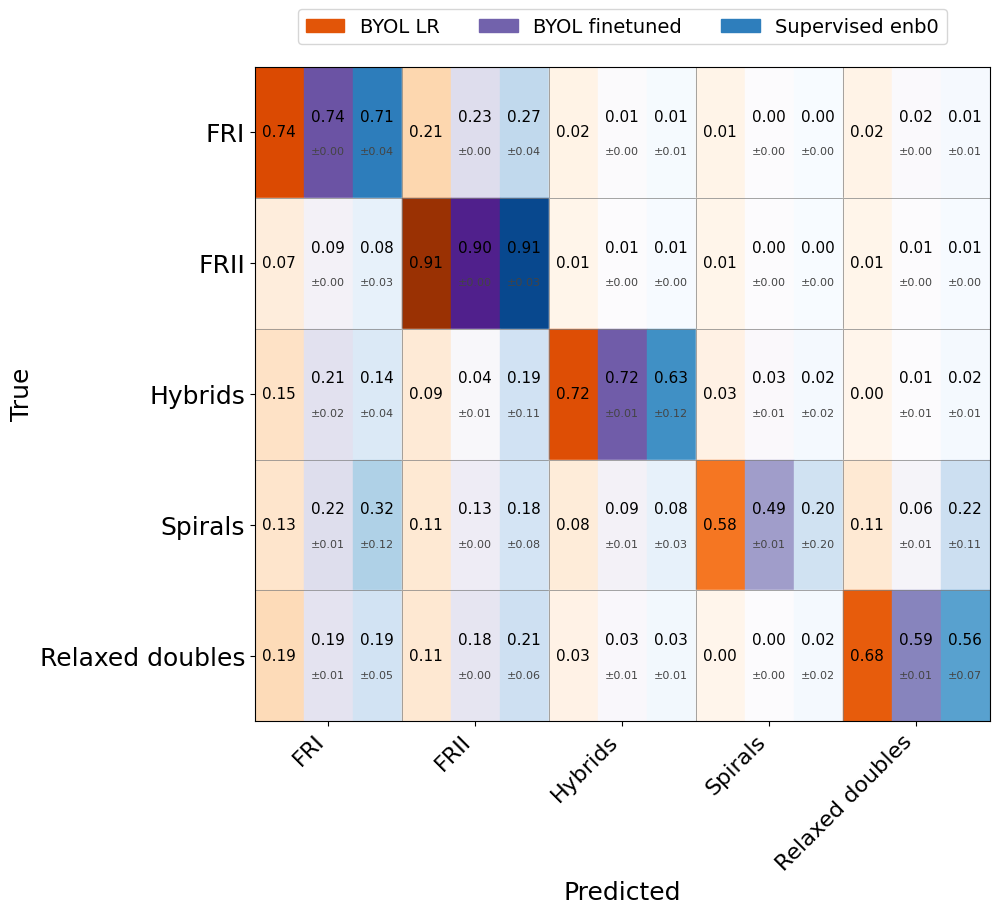

In [56]:
_class_names = [ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]]
n_cls = len(_class_names)

# ── BYOL confusion matrix ─────────────────────────────────────────────────────
cm_b   = confusion_matrix(y_te_byol, y_pred_byol, labels=list(range(n_cls)))
cm_b_n = cm_b / cm_b.sum(axis=1, keepdims=True).clip(min=1)

# ── Finetuning mode2 — per-run CMs for mean ± std ────────────────────────────
_ft_type = "finetuning_mode2_lr1e-4_ep30"
_ft_dir  = _run_dir / "data" / "classifiers" / _ft_type
_ft_run_norms, _ft_run_metrics = [], []
for _rp in sorted(_ft_dir.glob("run*/test_probs.npy")):
    _rl = _rp.parent / "test_labels.npy"
    if not _rl.exists():
        continue
    _p = np.load(_rp); _l = np.load(_rl)
    if _l.ndim == 2 and _l.shape[1] >= 5:
        _mask = _l[:, :5].sum(axis=1) == 1
        _p, _l = _p[_mask, :5], _l[_mask, :5]
    _yt = _l.argmax(axis=1) if _l.ndim == 2 else _l
    _yp = _p.argmax(axis=1)
    _cm_r = confusion_matrix(_yt, _yp, labels=list(range(n_cls)))
    _ft_run_norms.append(_cm_r / _cm_r.sum(axis=1, keepdims=True).clip(min=1))
    _ft_run_metrics.append({
        "F1":     f1_score(_yt, _yp, average="macro", zero_division=0),
        "AUC":    roc_auc_score(
                      label_binarize(_yt, classes=list(range(n_cls))),
                      _p, multi_class="ovr", average="macro"),
        "Acc":    accuracy_score(_yt, _yp),
        "Recall": recall_score(_yt, _yp, average="macro", zero_division=0),
    })

if _ft_run_norms:
    cm_ft_n   = np.mean(_ft_run_norms, axis=0)
    cm_ft_std = np.std(_ft_run_norms,  axis=0) if len(_ft_run_norms) > 1 else None
    _ft_metrics = {k: (float(np.mean([m[k] for m in _ft_run_metrics])),
                       float(np.std ([m[k] for m in _ft_run_metrics]))
                       if len(_ft_run_metrics) > 1 else None)
                   for k in ("F1", "AUC", "Acc", "Recall")}
    print(f"Finetuning mode2: {len(_ft_run_norms)} run(s)")
else:
    cm_ft_n = cm_ft_std = None
    _ft_metrics = {}
    print(f"Finetuning mode2: no predictions found in {_ft_dir}")

# ── Supervised baseline ───────────────────────────────────────────────────────
cm_s_n   = _cm_base_mean
cm_s_std = _cm_base_std

# ── Metrics table ─────────────────────────────────────────────────────────────
_byol_json = _clf_dir / f"{_clf_short}_{_ls}_projections.json"
with open(_byol_json) as _f:
    _bj = json.load(_f)
_byol_metrics = {
    "F1":     _bj["f1_macro"],
    "AUC":    _bj["auc_macro"],
    "Acc":    _bj["accuracy"],
    "Recall": _bj["recall_macro"],
}

print(f"\n{'Metric':<8}  {'BYOL':>6}  {'FT mode2 (mean ± std)':>22}  {'Base (mean ± std)':>18}")
print("-" * 62)
for k in ["F1", "AUC", "Acc", "Recall"]:
    mu_b, sd_b = _base_metrics_agg[k]
    s_base = f"{mu_b:.3f} ± {sd_b:.3f}" if sd_b is not None else f"{mu_b:.3f}"
    if _ft_metrics:
        mu_f, sd_f = _ft_metrics[k]
        s_ft = f"{mu_f:.3f} ± {sd_f:.3f}" if sd_f is not None else f"{mu_f:.3f}"
    else:
        s_ft = "N/A"
    print(f"{k:<8}  {_byol_metrics[k]:>6.3f}  {s_ft:>22}  {s_base:>18}")

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_b  = plt.cm.Oranges   # BYOL linear probe
cmap_ft = plt.cm.Purples   # Finetuned mode2
cmap_s  = plt.cm.Blues     # Supervised baseline

_w = 1 / 3  # width of each third

_clf_display = {"linear_probe": "LR", "random_forest": "RF", "knn": "KNN"}.get(
    CM_CONFIG["byol_classifier"], CM_CONFIG["byol_classifier"])

fig, ax = plt.subplots(figsize=(n_cls * 1.5 + 3, n_cls * 1.5 + 1))
plt.subplots_adjust(left=0.28, right=0.98)
ax.set_xlim(0, n_cls); ax.set_ylim(0, n_cls)
ax.invert_yaxis()

_n_runs_base = len(_base_run_norms)
_n_runs_ft   = len(_ft_run_norms)
for i in range(n_cls):
    for j in range(n_cls):
        # Left third — BYOL linear probe
        ax.add_patch(plt.Rectangle([j, i], _w, 1, color=cmap_b(cm_b_n[i, j])))
        ax.text(j + _w * 0.5, i + 0.5, f"{cm_b_n[i,j]:.2f}",
                ha="center", va="center", fontsize=11)

        # Middle third — Finetuned mode2 (mean ± std)
        _ft_val = cm_ft_n[i, j] if cm_ft_n is not None else 0.0
        ax.add_patch(plt.Rectangle([j + _w, i], _w, 1, color=cmap_ft(_ft_val)))
        if cm_ft_n is not None:
            ax.text(j + _w * 1.5, i + 0.38, f"{_ft_val:.2f}",
                    ha="center", va="center", fontsize=11)
            if cm_ft_std is not None:
                ax.text(j + _w * 1.5, i + 0.65, f"±{cm_ft_std[i,j]:.2f}",
                        ha="center", va="center", fontsize=8, color="#444444")

        # Right third — Supervised baseline (mean ± std)
        ax.add_patch(plt.Rectangle([j + 2*_w, i], _w, 1, color=cmap_s(cm_s_n[i, j])))
        ax.text(j + _w * 2.5, i + 0.38, f"{cm_s_n[i,j]:.2f}",
                ha="center", va="center", fontsize=11)
        if cm_s_std is not None:
            ax.text(j + _w * 2.5, i + 0.65, f"±{cm_s_std[i,j]:.2f}",
                    ha="center", va="center", fontsize=8, color="#444444")

        ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=False, edgecolor="grey", lw=0.5))

ax.set_xticks(np.arange(n_cls) + 0.5)
ax.set_xticklabels(_class_names, rotation=45, ha="right", fontsize=16)
ax.set_yticks(np.arange(n_cls) + 0.5)
ax.set_yticklabels(_class_names, fontsize=18)
ax.set_xlabel("Predicted", fontsize=18)
ax.set_ylabel("True", fontsize=18)

ax.legend(handles=[
    mpatches.Patch(color=plt.cm.Oranges(0.7), label=f"BYOL {_clf_display}"),
    mpatches.Patch(color=plt.cm.Purples(0.7), label=f"BYOL finetuned"),
    mpatches.Patch(color=plt.cm.Blues(0.7),   label=f"Supervised {CM_CONFIG['baseline_model']}"),
], loc="lower center", ncol=3, fontsize=14,
   bbox_to_anchor=(0.5, 1.02), frameon=True)

_run_name = _run_dir.name
plt.savefig(f"{OUT_DIR}/confusion_matrix_{_run_name}_{_ls}.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Label-Fraction Experiment

Train logistic regression probes on subsampled fractions of the train-split
projections. Tests how performance scales with the amount of labelled data,
evaluated on the fixed test split.

In [57]:

# ── Find runs in the vicinity of the configured checkpoint ────────────────────
# Reuses _fixed, _run_dirs, _parse_param from the Section 7 cell above.
# "Vicinity" = same fixed hyperparams (vicregvar, cov, gamma, ema)
#              AND same aug type AND same LR schedule type.

_KNOWN_AUG     = ["augquart_ext", "augquart", "augextended", "standard"]
_KNOWN_LR_TYPE = ["lrcosine", "lrconst", "lrcyclical"]

def _parse_aug(name):
    for aug in _KNOWN_AUG:
        if f"_{aug}_" in name or name.endswith(f"_{aug}"):
            return aug
    return None

def _parse_lr_type(name):
    # strip trailing timestamp before searching
    _n = re.sub(r'_\d{8}_\d{4}$', '', name)
    for lr in _KNOWN_LR_TYPE:
        if f"_{lr}" in _n:
            return lr
    return None

_ref_aug     = _parse_aug(_ref_name)
_ref_lr_type = _parse_lr_type(_ref_name)

_target_runs = [
    rd for rd in _run_dirs
    if all(
        _parse_param(rd.name, k) is not None and abs(_parse_param(rd.name, k) - v) < 1e-9
        for k, v in _fixed.items()
    )
    and (_ref_aug     is None or _parse_aug(rd.name)     == _ref_aug)
    and (_ref_lr_type is None or _parse_lr_type(rd.name) == _ref_lr_type)
]
print(f"Found {len(_target_runs)} runs (fixed={_fixed}, aug={_ref_aug}, lr={_ref_lr_type}):")
for rd in _target_runs:
    print(f"  {rd.name}")

# ── Load pre-computed label-fraction metrics (BYOL runs) ──────────────────────
fractions   = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]
_CACHE_FILE = "label_fraction_metrics.json"

def _load_metrics(run_dir):
    """Load label_fraction_metrics.json; return {float(f): data} or None."""
    cache_path = run_dir / "data" / "classifiers" / "simple_downstream" / _CACHE_FILE
    if not cache_path.exists():
        return None
    with open(cache_path) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None
    return loaded

def _load_single_point(run_dir):
    """Fall back to lr_initial_pure_projections.json for the 100% point."""
    p = run_dir / "data" / "classifiers" / "simple_downstream" / "lr_initial_pure_projections.json"
    if not p.exists():
        return None
    with open(p) as fp:
        d = json.load(fp)
    return {
        "f1":       d.get("f1_macro",     float("nan")),
        "auc":      d.get("auc_macro",    float("nan")),
        "accuracy": d.get("accuracy",     float("nan")),
        "recall":   d.get("recall_macro", float("nan")),
    }

all_frac_results  = {}  # {label: {f: {clf_name: {metric}}}} — full curves
single_pt_results = {}  # {label: {metric}}  — 100%-only star marker

def _unique_label(base, existing):
    """Append a counter suffix if base label already used."""
    if base not in existing:
        return base
    i = 2
    while f"{base} ({i})" in existing:
        i += 1
    return f"{base} ({i})"

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    _base_lbl = f"f={f_val} sw={sw_val}"
    cached = _load_metrics(rd)
    if cached is not None:
        label = _unique_label(_base_lbl, all_frac_results)
        all_frac_results[label] = cached
        print(f"→ {label}  (full fraction curve loaded)")
    else:
        sp = _load_single_point(rd)
        if sp is not None:
            label = _unique_label(_base_lbl, {**all_frac_results, **single_pt_results})
            single_pt_results[label] = sp
            print(f"★ {label}  (100% only — run train_byol_classifiers.py to get full curve)")
        else:
            print(f"✗ {_base_lbl}  no cache")

# ── Supervised baselines — fraction curves ────────────────────────────────────
# Each baseline run dir saves its own label_fraction_metrics.json (one per run).
# We rglob all of them, group by model label, and compute mean ± std across runs.
_baselines_dir = Path(CONFIG["baselines_dir"])
baseline_frac_results = {}  # {model_label: {f: {"Supervised": {metric, metric_std}}}}
baseline_scalars      = {}  # {model_label: {metric, metric_std}} — fallback (no fraction data)

if _baselines_dir.exists():
    _bl_frac_by_model: dict = {}
    for _rj in sorted(_baselines_dir.rglob(_CACHE_FILE)):
        with open(_rj) as _f:
            _frd = json.load(_f)
        if not _frd:
            continue
        _first = next(iter(_frd.values()))
        if "Supervised" not in _first:
            continue
        _bl_frac_by_model.setdefault("Supervised (enb0)", []).append(_frd)

    for _mk, _frd_list in _bl_frac_by_model.items():
        _all_fs = sorted({float(k) for _fd in _frd_list for k in _fd})
        _agg = {}
        for _fs in _all_fs:
            _vals = [_fd[str(_fs)]["Supervised"]
                     for _fd in _frd_list
                     if str(_fs) in _fd and "Supervised" in _fd.get(str(_fs), {})]
            if not _vals:
                continue
            _agg[_fs] = {"Supervised": {
                m: float(np.mean([v[m] for v in _vals]))
                for m in ("f1", "auc", "accuracy", "recall")
            }}
            for m in ("f1", "auc", "accuracy", "recall"):
                _raw = [v[m] for v in _vals]
                _agg[_fs]["Supervised"][f"{m}_std"] = (
                    float(np.std(_raw)) if len(_raw) > 1 else None
                )
        if _agg:
            baseline_frac_results[_mk] = _agg
            print(f"Baseline fraction curve: {_mk} ({len(_frd_list)} run(s), "
                  f"{len(_agg)} fractions)")

    _bl_scalar_runs = []
    for _rj in sorted(_baselines_dir.rglob("results.json")):
        with open(_rj) as _f:
            _r = json.load(_f)
        if len(_r.get("class_names", [])) == 5:
            _bl_scalar_runs.append(_r)
    if _bl_scalar_runs and not baseline_frac_results:
        _f1s  = [r["f1_macro"]  for r in _bl_scalar_runs]
        _aucs = [r["auc_macro"] for r in _bl_scalar_runs]
        _accs = [r["accuracy"]  for r in _bl_scalar_runs]
        baseline_scalars["Supervised (enb0)"] = {
            "f1": float(np.mean(_f1s)), "f1_std": float(np.std(_f1s)) if len(_f1s) > 1 else None,
            "auc": float(np.mean(_aucs)), "auc_std": float(np.std(_aucs)) if len(_aucs) > 1 else None,
            "accuracy": float(np.mean(_accs)), "accuracy_std": float(np.std(_accs)) if len(_accs) > 1 else None,
            "recall": float("nan"),
        }
        print(f"Baseline scalar (fallback): {len(_bl_scalar_runs)} run(s)  "
              f"F1={np.mean(_f1s):.3f}±{np.std(_f1s):.3f}")
else:
    print(f"Baselines dir not found: {_baselines_dir}")

# ── Finetuning results — load from per-run test_probs.npy ────────────────────
# Structure produced by train_finetuning.py:
#   data/classifiers/finetuning_{name}/run{i}/test_probs.npy   ← 100% label fraction
#   data/classifiers/finetuning_{name}/frac_{f:.2f}/run{i}/test_probs.npy  ← sweep fractions
#
# For each finetuning variant we build:
#   finetuning_points      {label: {metric: mean, metric_std: std}} — 100% only
#   finetuning_frac_curves {label: {frac: {metric: mean, metric_std: std}}}
from sklearn.metrics import (f1_score as _f1_score, accuracy_score as _acc_score,
                              roc_auc_score as _auc_score, recall_score as _rec_score)
from sklearn.preprocessing import label_binarize as _label_binarize

_FT_METRICS = ("f1", "accuracy", "recall", "auc")

def _probs_to_metrics(prob_path):
    """Load test_probs/labels, apply initial_pure filter, return per-class metrics dict."""
    _lab_path = prob_path.parent / "test_labels.npy"
    if not _lab_path.exists():
        return None
    _p = np.load(prob_path)
    _l = np.load(_lab_path)
    if _l.ndim == 2 and _l.shape[1] >= 5:
        _mask = _l[:, :5].sum(axis=1) == 1
    elif _l.ndim == 1:
        _mask = np.ones(len(_l), dtype=bool)
    else:
        return None
    _p5 = _p[_mask, :5]
    _l5 = _l[_mask, :5] if _l.ndim == 2 else _l[_mask]
    if len(_p5) == 0:
        return None
    _yt = _l5.argmax(axis=1) if _l5.ndim == 2 else _l5
    _yp = _p5.argmax(axis=1)
    try:
        _auc_v = _auc_score(
            _label_binarize(_yt, classes=list(range(_p5.shape[1]))),
            _p5, multi_class="ovr", average="macro")
    except Exception:
        _auc_v = float("nan")
    return {
        "f1":       _f1_score(_yt, _yp, average="macro", zero_division=0),
        "accuracy": _acc_score(_yt, _yp),
        "recall":   _rec_score(_yt, _yp, average="macro", zero_division=0),
        "auc":      _auc_v,
    }

def _aggregate_runs(run_metrics_list):
    """Aggregate a list of per-run metric dicts into mean ± std."""
    _agg = {m: float(np.mean([r[m] for r in run_metrics_list])) for m in _FT_METRICS}
    if len(run_metrics_list) > 1:
        _agg.update({f"{m}_std": float(np.std([r[m] for r in run_metrics_list]))
                     for m in _FT_METRICS})
    return _agg

finetuning_points      = {}  # {label: {metric: mean, ...}}
finetuning_frac_curves = {}  # {label: {frac: {metric: mean, ...}}}

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    for _ft_dir in sorted((rd / "data" / "classifiers").glob("finetuning_*")):
        _lbl = f"f={f_val} sw={sw_val} [{_ft_dir.name}]"

        # 100% point — from run*/test_probs.npy directly in finetuning dir
        _run_ms = [m for pp in sorted(_ft_dir.glob("run*/test_probs.npy"))
                   if (m := _probs_to_metrics(pp)) is not None]
        if _run_ms:
            finetuning_points[_lbl] = _aggregate_runs(_run_ms)
            print(f"Finetuning 100%: {_lbl}  F1={finetuning_points[_lbl]['f1']:.3f}"
                  f"  ({len(_run_ms)} run(s))")

        # Sub-100% sweep — from frac_*/run*/test_probs.npy
        _frac_curve = {}
        for _frac_subdir in sorted(_ft_dir.glob("frac_*")):
            try:
                _fv = float(_frac_subdir.name.replace("frac_", ""))
            except ValueError:
                continue
            _fms = [m for pp in sorted(_frac_subdir.glob("run*/test_probs.npy"))
                    if (m := _probs_to_metrics(pp)) is not None]
            if _fms:
                _frac_curve[_fv] = _aggregate_runs(_fms)
        if _frac_curve:
            # Merge 100% point into curve if available
            if _lbl in finetuning_points:
                _frac_curve[1.0] = finetuning_points[_lbl]
            finetuning_frac_curves[_lbl] = _frac_curve
            print(f"Finetuning curve: {_lbl}  fractions={sorted(_frac_curve.keys())}")

print(f"\nLoaded {len(all_frac_results)} BYOL curve(s),  "
      f"{len(single_pt_results)} single-point(s),  "
      f"{len(baseline_frac_results)} baseline curve(s),  "
      f"{len(baseline_scalars)} baseline scalar(s),  "
      f"{len(finetuning_points)} finetuning 100%-point(s),  "
      f"{len(finetuning_frac_curves)} finetuning curve(s).")


Found 6 runs (fixed={'vicregvar': 2.0, 'cov': 0.1, 'gamma': 0.25, 'ema': 0.996}, aug=augquart_ext, lr=lrconst):
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260713_1242
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw3_augquart_ext_20260713_1249
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.0_augquart_ext_20260709_2117
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.5_augquart_ext_20260709_2253
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw1.0_augquart_ext_20260709_2345
✗ f=0.1 sw=3.0  no cache
✗ f=0.5 sw=3.0  no cache
→ f=1.0 sw=0.05  (full fraction curve loaded)
→ f=1.0 sw=0.0  (full fraction curve loaded)
→ f=1.0 sw=0.5  (full fraction curve loaded)
→ f=1

=== Model paths ===
Reference checkpoint : ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/byol_model_best.pt
Reference run        : enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203

BYOL target runs (6):
  [no data] ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.1_sw3_augquart_ext_20260713_1242
  [no data] ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f0.5_sw3_augquart_ext_20260713_1249
  [full curve] ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203
  [full curve] ../outputs/byol_runs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.0_augquart_ext_20260709_2117
  [full curve] ../outputs/byol_runs/enb0_mlp_p

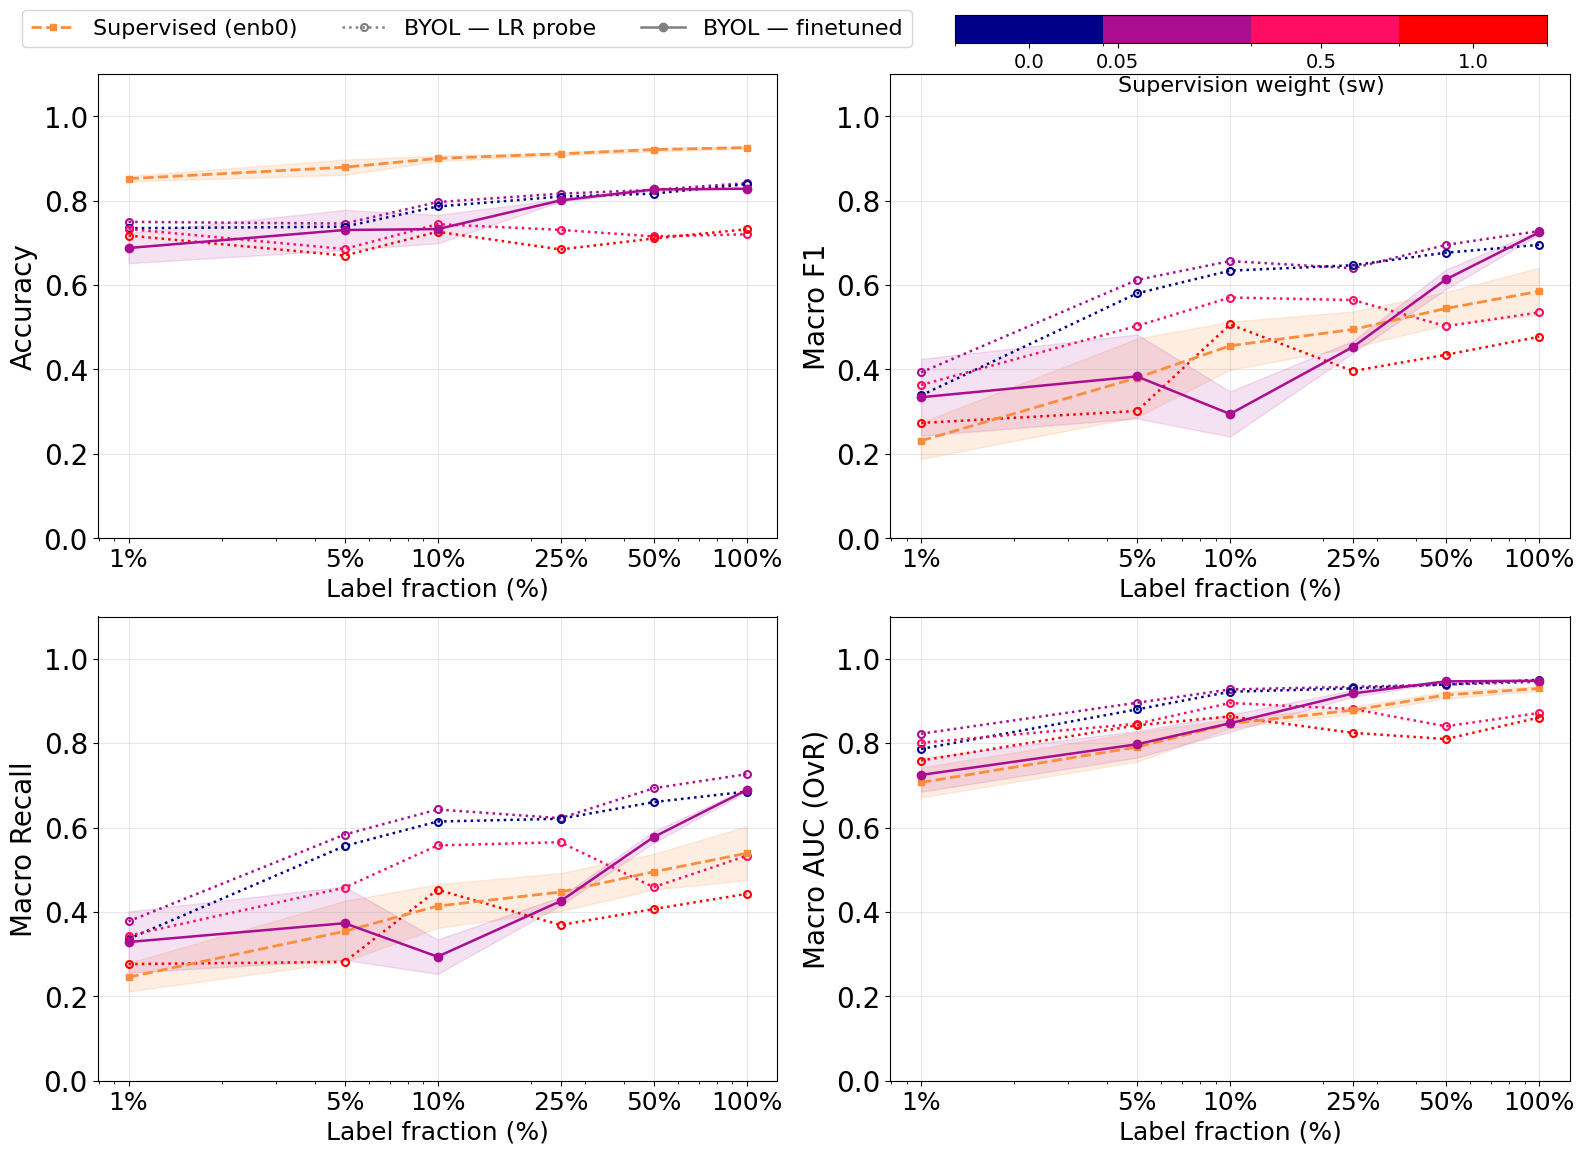

Saved → ../outputs/figures/classification/label_fraction_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203.png


In [58]:
# ── Print all model paths used in this plot ───────────────────────────────────
print("=== Model paths ===")
print(f"Reference checkpoint : {CONFIG['checkpoint']}")
print(f"Reference run        : {_ref_name}")
print(f"\nBYOL target runs ({len(_target_runs)}):")
for _rd in _target_runs:
    _lbl = f"f={_parse_param(_rd.name, 'f')} sw={_parse_param(_rd.name, 'sw')}"
    _in_frac = _lbl in all_frac_results or any(_lbl in k for k in all_frac_results)
    _in_sp   = _lbl in single_pt_results or any(_lbl in k for k in single_pt_results)
    _status  = "full curve" if _in_frac else ("100% only" if _in_sp else "no data")
    print(f"  [{_status}] {_rd}")
print(f"\nBaseline fraction curves ({len(baseline_frac_results)}): {list(baseline_frac_results.keys())}")
print(f"Baseline scalars      ({len(baseline_scalars)}): {list(baseline_scalars.keys())}")
_ft_all = {**finetuning_points, **finetuning_frac_curves}
print(f"\nFinetuning results ({len(_ft_all)}):")
for _k in sorted(_ft_all):
    print(f"  {_k}")
print()

_metrics    = [("accuracy", "Accuracy"), ("f1", "Macro F1"),
               ("recall", "Macro Recall"), ("auc", "Macro AUC (OvR)")]

# ── Filter finetuning dicts to mode2 only ─────────────────────────────────────
_ft_points_plot = {k: v for k, v in finetuning_points.items() if "mode2" in k}
_ft_curves_plot = {k: v for k, v in finetuning_frac_curves.items() if "mode2" in k}

# ── Discrete colour mapping: one colour per unique sw value ───────────────────
def _sw_from_label(lbl):
    m = re.search(r'sw=([\d.]+)', lbl)
    return float(m.group(1)) if m else None

_sw_cmap_cont = mcolors.LinearSegmentedColormap.from_list(
    "sw_cmap", ["darkblue", "deeppink", "red"]
)
_all_run_labels = (list(all_frac_results.keys())
                   + [l for l in single_pt_results if l not in all_frac_results]
                   + list(_ft_points_plot.keys())
                   + [l for l in _ft_curves_plot if l not in _ft_points_plot])
_all_sw = [_sw_from_label(l) for l in _all_run_labels]
_sw_vals = [v for v in _all_sw if v is not None]
_sw_vals_unique = sorted(set(_sw_vals)) if _sw_vals else [0.0]
_n_sw = len(_sw_vals_unique)

# Sample one colour per unique sw value, spread evenly over the full cmap range
_sw_color_list = [_sw_cmap_cont(i / max(_n_sw - 1, 1)) for i in range(_n_sw)]
_sw_color_map  = dict(zip(_sw_vals_unique, _sw_color_list))
_run_colors    = {lbl: (_sw_color_map.get(sw, "grey") if sw is not None else "grey")
                  for lbl, sw in zip(_all_run_labels, _all_sw)}

# Discrete ListedColormap + BoundaryNorm for the colorbar
_disc_cmap = mcolors.ListedColormap(_sw_color_list)
if _n_sw == 1:
    _bounds = [_sw_vals_unique[0] - 0.05, _sw_vals_unique[0] + 0.05]
else:
    _gaps = [(_sw_vals_unique[i+1] - _sw_vals_unique[i]) / 2 for i in range(_n_sw - 1)]
    _bounds = (
        [_sw_vals_unique[0] - _gaps[0]]
        + [(_sw_vals_unique[i] + _sw_vals_unique[i+1]) / 2 for i in range(_n_sw - 1)]
        + [_sw_vals_unique[-1] + _gaps[-1]]
    )
_disc_norm = mcolors.BoundaryNorm(_bounds, _disc_cmap.N)

_bl_labels  = list(baseline_frac_results.keys()) + list(baseline_scalars.keys())
_bl_all     = sorted(set(_bl_labels))
_bl_palette = plt.cm.Oranges(np.linspace(0.5, 0.85, max(len(_bl_all), 1)))
_bl_colors  = {lbl: _bl_palette[i] for i, lbl in enumerate(_bl_all)}

xs_pct = [f * 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (metric, ylabel) in zip(axes, _metrics):
    # BYOL full label-fraction curves — dotted lines with hollow circles
    for run_lbl, res in all_frac_results.items():
        ys = [res[f]["LogReg"][metric] for f in fractions]
        ax.plot(xs_pct, ys, linestyle=":", color=_run_colors[run_lbl],
                linewidth=1.8, marker="o", markersize=5,
                markerfacecolor="none", markeredgewidth=1.5)

    # BYOL 100%-only fallback — hollow circle at x=100
    for sp_lbl, sp in single_pt_results.items():
        v = sp.get(metric, float("nan"))
        if v == v:
            ax.plot(100, v, marker="o", markersize=7, linestyle="none",
                    color=_run_colors[sp_lbl],
                    markerfacecolor="none", markeredgewidth=1.5, zorder=5)

    # Supervised baseline fraction curves with shaded std bands
    for bl_lbl, bl_res in baseline_frac_results.items():
        bl_fs  = sorted(bl_res.keys())
        bl_xs  = [f * 100 for f in bl_fs]
        ys     = [bl_res[f]["Supervised"].get(metric, float("nan")) for f in bl_fs]
        ys_std = [bl_res[f]["Supervised"].get(f"{metric}_std") for f in bl_fs]
        col    = _bl_colors[bl_lbl]
        ax.plot(bl_xs, ys, linestyle="--", color=col, linewidth=2.0, marker="s", markersize=5)
        _lo = [y - (s if s is not None else 0) for y, s in zip(ys, ys_std)]
        _hi = [y + (s if s is not None else 0) for y, s in zip(ys, ys_std)]
        if any(s is not None for s in ys_std):
            ax.fill_between(bl_xs, _lo, _hi, color=col, alpha=0.15)

    # Supervised baseline scalar fallback — single square at 100%
    for bl_lbl, bl in baseline_scalars.items():
        v = bl.get(metric, float("nan"))
        if v == v:
            col = _bl_colors[bl_lbl]
            ax.plot(100, v, marker="s", markersize=8, color=col,
                    linestyle="none", zorder=5)
            std = bl.get(f"{metric}_std")
            if std:
                ax.errorbar(100, v, yerr=std, fmt="none", color=col,
                            capsize=4, linewidth=1.5)

    # Finetuning full curves — solid lines with filled circles
    for ft_lbl, ft_curve in _ft_curves_plot.items():
        ft_fs = sorted(ft_curve.keys())
        ft_xs = [f * 100 for f in ft_fs]
        ys    = [ft_curve[f].get(metric, float("nan")) for f in ft_fs]
        stds  = [ft_curve[f].get(f"{metric}_std") for f in ft_fs]
        col   = _run_colors.get(ft_lbl, "grey")
        ax.plot(ft_xs, ys, linestyle="-", color=col, linewidth=1.8,
                marker="o", markersize=6, zorder=6)
        _lo = [y - (s if s is not None else 0) for y, s in zip(ys, stds)]
        _hi = [y + (s if s is not None else 0) for y, s in zip(ys, stds)]
        if any(s is not None for s in stds):
            ax.fill_between(ft_xs, _lo, _hi, color=col, alpha=0.12)

    # Finetuning 100%-only fallback — single filled circle at x=100
    for ft_lbl, ft in _ft_points_plot.items():
        if ft_lbl in _ft_curves_plot:
            continue  # already plotted as a full curve above
        v = ft.get(metric, float("nan"))
        if v != v:
            continue
        col = _run_colors.get(ft_lbl, "grey")
        ax.plot(100, v, linestyle="-", marker="o", markersize=7,
                color=col, zorder=6)
        std = ft.get(f"{metric}_std")
        if std:
            ax.errorbar(100, v, yerr=std, fmt="none", color=col,
                        capsize=4, linewidth=1.5, zorder=6)

    ax.set_xscale("log")
    ax.set_xlabel("Label fraction (%)", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(xs_pct)
    ax.set_xticklabels([f"{x:.0f}%" for x in xs_pct], fontsize=18)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── Legend — top-left ──────────────────────────────────────────────────────────
_legend_handles = []
for lbl in baseline_frac_results:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="--",
                   linewidth=2.0, marker="s", markersize=5, label=lbl))
for lbl in baseline_scalars:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="none",
                   marker="s", markersize=8, label=f"{lbl} (100% only)"))
_legend_handles.append(
    plt.Line2D([0], [0], color="grey", linestyle=":", linewidth=1.8,
               marker="o", markersize=5, markerfacecolor="none", markeredgewidth=1.5,
               label="BYOL — LR probe"))
if _ft_curves_plot or _ft_points_plot:
    _legend_handles.append(
        plt.Line2D([0], [0], color="grey", linestyle="-", linewidth=1.8,
                   marker="o", markersize=6, label="BYOL — finetuned"))
if _legend_handles:
    fig.legend(handles=_legend_handles, loc="upper left",
               ncol=len(_legend_handles), fontsize=16,
               bbox_to_anchor=(0.01, 1.055), frameon=True)

# ── Discrete horizontal colorbar — top-right ───────────────────────────────────
_sm_disc = plt.cm.ScalarMappable(cmap=_disc_cmap, norm=_disc_norm)
_sm_disc.set_array([])
_cbar_ax = fig.add_axes([0.60, 1.015, 0.37, 0.025])
_cbar = fig.colorbar(_sm_disc, cax=_cbar_ax, orientation="horizontal")
_cbar.set_ticks(_sw_vals_unique)
_cbar.set_ticklabels([str(v) for v in _sw_vals_unique], fontsize=14)
_cbar.set_label("Supervision weight (sw)", fontsize=16, labelpad=3)

_out = f"{OUT_DIR}/label_fraction_{_ref_name}.png"
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_out}")

## 10. Generative Augmentation Experiment

Performance as a function of the fraction of generated images added to the training set.
Baseline (gen fraction = 0) comes from the supervised run without generative data.

Found 3 gen_aug dir(s):
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203_enb0_20260713_1239/gen_aug
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203_enb0_20260713_1708/gen_aug
  enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203_enb0_20260713_1713/gen_aug
Gen fracs available: [0.5, 1.0, 2.0]


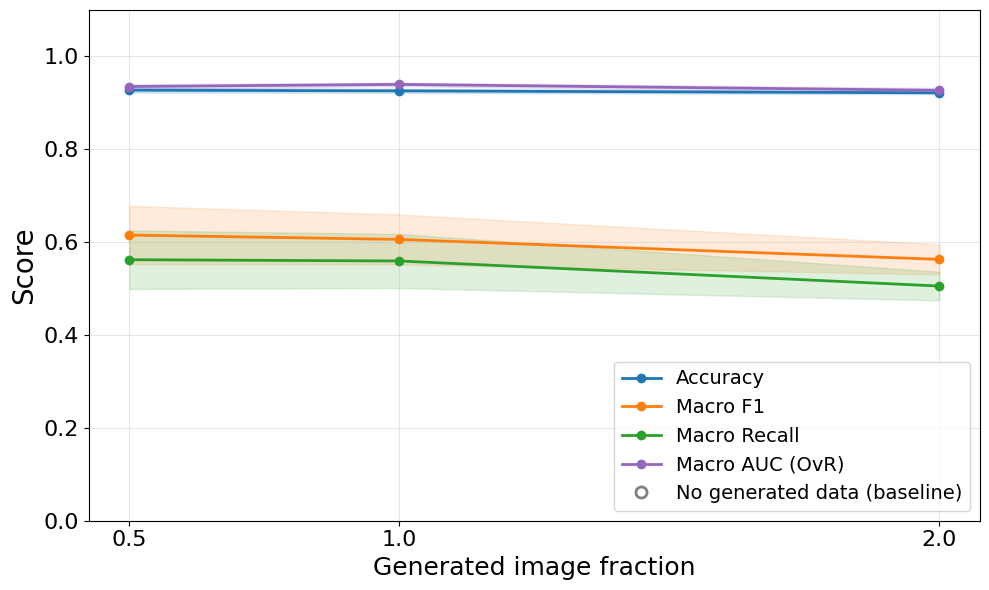

Saved → ../outputs/figures/classification/gen_aug_performance_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar2_cov0.1_gamma0.25_f1_sw0.05_augquart_ext_20260709_2203.png


In [59]:
# ── Find all gen_aug dirs under baselines_dir/with_generative ─────────────────
_gen_basedir = Path(CONFIG["baselines_dir"]) / "with_generative"
_gen_aug_dirs = sorted(_gen_basedir.rglob("gen_aug")) if _gen_basedir.exists() else []
print(f"Found {len(_gen_aug_dirs)} gen_aug dir(s):")
for _d in _gen_aug_dirs:
    print(f"  {_d.relative_to(_gen_basedir)}")

_GA_METRICS = [
    ("accuracy",     "Accuracy"),
    ("f1_macro",     "Macro F1"),
    ("recall_macro", "Macro Recall"),
    ("auc_macro",    "Macro AUC (OvR)"),
]
_GA_KEYS = [m for m, _ in _GA_METRICS]

# ── Baseline (frac=0): from the latest gen_aug dir's run_summary.json ─────────
_gen_baseline = {}
if _gen_aug_dirs:
    _latest_rs = _gen_aug_dirs[-1].parent / "run_summary.json"
    if _latest_rs.exists():
        with open(_latest_rs) as _fp:
            _rs = json.load(_fp)
        for _mk in _GA_KEYS:
            if _mk in _rs.get("per_metric", {}):
                _gen_baseline[_mk] = (
                    _rs["per_metric"][_mk]["mean"],
                    _rs["per_metric"][_mk]["std"],
                )
        print(f"Baseline from: {_latest_rs.parent.name}")

# ── Gen-frac data: aggregate run*/results.json across all gen_aug dirs ────────
_all_frac_vals = {}  # {gfrac: {mkey: [per-run values]}}
for _gad in _gen_aug_dirs:
    for _fdir in sorted(_gad.glob("frac_*")):
        try:
            _gf = float(_fdir.name.replace("frac_", ""))
        except ValueError:
            continue
        _bucket = _all_frac_vals.setdefault(_gf, {_mk: [] for _mk in _GA_KEYS})
        for _rj in sorted(_fdir.glob("run*/results.json")):
            with open(_rj) as _fp:
                _r = json.load(_fp)
            for _mk in _GA_KEYS:
                if _mk in _r:
                    _bucket[_mk].append(float(_r[_mk]))

# Build {gfrac: {mkey: (mean, std)}}
_gen_agg = {}
if _gen_baseline:
    _gen_agg[0.0] = {_mk: _gen_baseline[_mk] for _mk in _GA_KEYS if _mk in _gen_baseline}
for _gf, _mdict in sorted(_all_frac_vals.items()):
    _gen_agg[_gf] = {
        _mk: (float(np.mean(_vs)), float(np.std(_vs)) if len(_vs) > 1 else 0.0)
        for _mk, _vs in _mdict.items() if _vs
    }

_gen_fracs = sorted(_gen_agg.keys())
print(f"Gen fracs available: {_gen_fracs}")

# ── Plot — single frame, colour per metric ────────────────────────────────────
_ga_colors = plt.cm.tab10(np.linspace(0, 0.4, len(_GA_METRICS)))

fig, ax = plt.subplots(figsize=(10, 6))

for (metric, label), color in zip(_GA_METRICS, _ga_colors):
    _xs   = [_gf for _gf in _gen_fracs if metric in _gen_agg[_gf]]
    _ys   = [_gen_agg[_gf][metric][0] for _gf in _xs]
    _stds = [_gen_agg[_gf][metric][1] for _gf in _xs]

    ax.plot(_xs, _ys, linestyle="-", color=color, linewidth=2.0,
            marker="o", markersize=6, label=label, zorder=5)
    _lo = [y - s for y, s in zip(_ys, _stds)]
    _hi = [y + s for y, s in zip(_ys, _stds)]
    if any(s > 0 for s in _stds):
        ax.fill_between(_xs, _lo, _hi, color=color, alpha=0.15)

    # Baseline (frac=0) — hollow circle with error bar
    if 0.0 in _gen_agg and metric in _gen_agg[0.0]:
        _v, _s = _gen_agg[0.0][metric]
        ax.plot(0.0, _v, marker="o", markersize=8, color=color,
                markerfacecolor="none", markeredgewidth=2.0,
                linestyle="none", zorder=6)
        if _s > 0:
            ax.errorbar(0.0, _v, yerr=_s, fmt="none", color=color,
                        capsize=4, linewidth=1.5, zorder=6)

ax.set_xlabel("Generated image fraction", fontsize=18)
ax.set_ylabel("Score", fontsize=20)
ax.set_xticks(_gen_fracs)
ax.set_xticklabels([str(_gf) for _gf in _gen_fracs], fontsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

# Legend: metrics + marker explanation
_legend_handles = [
    plt.Line2D([0], [0], color=c, linewidth=2.0, marker="o", markersize=6, label=lbl)
    for (_, lbl), c in zip(_GA_METRICS, _ga_colors)
] + [
    plt.Line2D([0], [0], color="grey", marker="o", markersize=8, linestyle="none",
               markerfacecolor="none", markeredgewidth=2.0, label="No generated data (baseline)"),
]
ax.legend(handles=_legend_handles, fontsize=14, loc="lower right", frameon=True)

plt.tight_layout()
_out = f"{OUT_DIR}/gen_aug_performance_{_ref_name}.png"
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_out}")